In [3]:
import pandas as pd

df = pd.read_excel('../data/Aprobacion curso 2019.xlsx')
#df = pd.read_excel('/content/drive/MyDrive/Curso EAM 4/Carpeta del Curso Analítica Predictiva/Aprobacion curso 2019.xlsx')
display(df.head())


,ID,Año - Semestre,Felder,Examen_admisión_Universidad,Nota_Curso_Calculo,Aprobo_Calculo
0,1,2016-01,sensorial,4.67,3.1,si
1,2,2016-01,activo,4.17,2.1,no
2,3,2016-01,visual,4.50,3.1,si
3,4,2016-01,visual,3.83,1.6,no
4,5,2016-01,equilibrio,3.00,2.3,no


In [4]:
df = df.drop(df.columns[[0, 1, 4]], axis=1)
display(df.head())

,Felder,Examen_admisión_Universidad,Aprobo_Calculo
0,sensorial,4.67,si
1,activo,4.17,no
2,visual,4.50,si
3,visual,3.83,no
4,equilibrio,3.00,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Felder                       183 non-null    object 
 1   Examen_admisión_Universidad  181 non-null    float64
 2   Aprobo_Calculo               183 non-null    object 
dtypes: float64(1), object(2)
memory usage: 4.4+ KB


In [6]:
for col in ['Felder', 'Aprobo_Calculo']:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Felder                       183 non-null    category
 1   Examen_admisión_Universidad  181 non-null    float64 
 2   Aprobo_Calculo               183 non-null    category
dtypes: category(2), float64(1)
memory usage: 2.4 KB


In [7]:
#%pip install ydata-profiling

In [8]:
#from ydata_profiling import ProfileReport

#profile = ProfileReport(df, title="Profiling Report")
#profile.to_notebook_iframe()

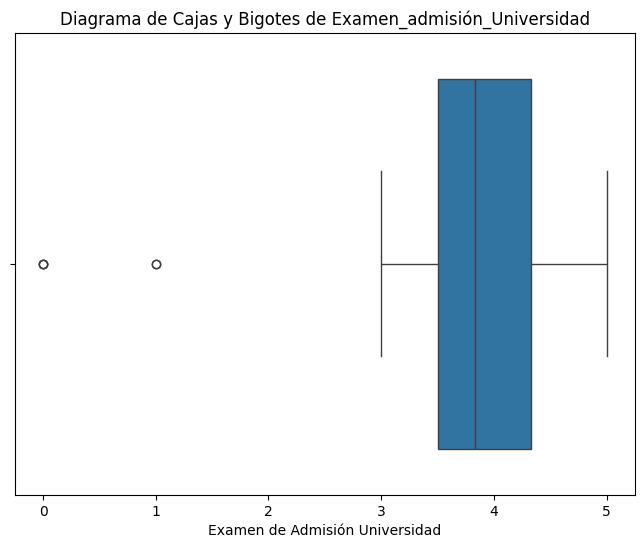

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Examen_admisión_Universidad'])
plt.title('Diagrama de Cajas y Bigotes de Examen_admisión_Universidad')
plt.xlabel('Examen de Admisión Universidad')
plt.show()

In [10]:
import numpy as np

Q1 = df['Examen_admisión_Universidad'].quantile(0.25)
Q3 = df['Examen_admisión_Universidad'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Examen_admisión_Universidad'] = np.where(
    (df['Examen_admisión_Universidad'] < lower_bound) | (df['Examen_admisión_Universidad'] > upper_bound),
    np.nan,
    df['Examen_admisión_Universidad']
)

display(df.head())

,Felder,Examen_admisión_Universidad,Aprobo_Calculo
0,sensorial,4.67,si
1,activo,4.17,no
2,visual,4.50,si
3,visual,3.83,no
4,equilibrio,3.00,no


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Felder                       183 non-null    category
 1   Examen_admisión_Universidad  176 non-null    float64 
 2   Aprobo_Calculo               183 non-null    category
dtypes: category(2), float64(1)
memory usage: 2.4 KB


In [12]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df['Examen_admisión_Universidad'] = imputer.fit_transform(df[['Examen_admisión_Universidad']])

display(df.head())
df.info()

,Felder,Examen_admisión_Universidad,Aprobo_Calculo
0,sensorial,4.67,si
1,activo,4.17,no
2,visual,4.50,si
3,visual,3.83,no
4,equilibrio,3.00,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Felder                       183 non-null    category
 1   Examen_admisión_Universidad  183 non-null    float64 
 2   Aprobo_Calculo               183 non-null    category
dtypes: category(2), float64(1)
memory usage: 2.4 KB


In [13]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [14]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Select the 'Felder' column for encoding
felder_column = df[['Felder']]

# Initialize OneHotEncoder
# handle_unknown='ignore' is used to handle potential new categories during prediction
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the 'Felder' column
felder_encoded = encoder.fit_transform(felder_column)

# Create a DataFrame from the encoded features
# Get feature names for the encoded columns
encoded_feature_names = encoder.get_feature_names_out(['Felder'])
felder_encoded_df = pd.DataFrame(felder_encoded, columns=encoded_feature_names, index=df.index)

# Drop the original 'Felder' column and concatenate the encoded features
df_encoded = df.drop('Felder', axis=1)
df_encoded = pd.concat([df_encoded, felder_encoded_df], axis=1)

display(df_encoded.head())
df_encoded.info()

,Examen_admisión_Universidad,Aprobo_Calculo,Felder_activo,Felder_equilibrio,Felder_intuitivo,Felder_reflexivo,Felder_secuencial,Felder_sensorial,Felder_verbal,Felder_visual
0,4.67,si,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,4.17,no,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.50,si,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3.83,no,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,3.00,no,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Examen_admisión_Universidad  183 non-null    float64 
 1   Aprobo_Calculo               183 non-null    category
 2   Felder_activo                183 non-null    float64 
 3   Felder_equilibrio            183 non-null    float64 
 4   Felder_intuitivo             183 non-null    float64 
 5   Felder_reflexivo             183 non-null    float64 
 6   Felder_secuencial            183 non-null    float64 
 7   Felder_sensorial             183 non-null    float64 
 8   Felder_verbal                183 non-null    float64 
 9   Felder_visual                183 non-null    float64 
dtypes: category(1), float64(9)
memory usage: 13.3 KB


In [15]:
import joblib
# Save the encoder
joblib.dump(encoder, '../scripts/models/clasificacion/onehotencoder.pkl')
print("OneHotEncoder saved as onehotencoder.pkl")

OneHotEncoder saved as onehotencoder.pkl


In [16]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming 'Aprobo_Calculo' is your target variable
X = df_encoded.drop('Aprobo_Calculo', axis=1)
y = df_encoded['Aprobo_Calculo']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Shape of original data:", X.shape, y.shape)
print("Shape of resampled data:", X_resampled.shape, y_resampled.shape)
print("\nClass distribution of original data:\n", y.value_counts())
print("\nClass distribution of resampled data:\n", y_resampled.value_counts())

display(X_resampled.head())

Shape of original data: (183, 9) (183,)
Shape of resampled data: (216, 9) (216,)

Class distribution of original data:
 Aprobo_Calculo
no    108
si     75
Name: count, dtype: int64

Class distribution of resampled data:
 Aprobo_Calculo
no    108
si    108
Name: count, dtype: int64


,Examen_admisión_Universidad,Felder_activo,Felder_equilibrio,Felder_intuitivo,Felder_reflexivo,Felder_secuencial,Felder_sensorial,Felder_verbal,Felder_visual
0,4.67,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,4.17,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3.83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,3.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
import pandas as pd
# Concatenate X_resampled and y_resampled
df_resampled = pd.concat([X_resampled, y_resampled], axis=1)

display(df_resampled.head())
df_resampled.info()

,Examen_admisión_Universidad,Felder_activo,Felder_equilibrio,Felder_intuitivo,Felder_reflexivo,Felder_secuencial,Felder_sensorial,Felder_verbal,Felder_visual,Aprobo_Calculo
0,4.67,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,si
1,4.17,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,no
2,4.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,si
3,3.83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,no
4,3.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Examen_admisión_Universidad  216 non-null    float64 
 1   Felder_activo                216 non-null    float64 
 2   Felder_equilibrio            216 non-null    float64 
 3   Felder_intuitivo             216 non-null    float64 
 4   Felder_reflexivo             216 non-null    float64 
 5   Felder_secuencial            216 non-null    float64 
 6   Felder_sensorial             216 non-null    float64 
 7   Felder_verbal                216 non-null    float64 
 8   Felder_visual                216 non-null    float64 
 9   Aprobo_Calculo               216 non-null    category
dtypes: category(1), float64(9)
memory usage: 15.6 KB


In [18]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Reshape the column to be 2D for the scaler
examen_admision_resampled_reshaped = df_resampled['Examen_admisión_Universidad'].values.reshape(-1, 1)

# Apply Min-Max scaling to the resampled data
df_resampled['Examen_admisión_Universidad_scaled'] = scaler.fit_transform(examen_admision_resampled_reshaped)

# Display the scaled column and the original for comparison
display(df_resampled[['Examen_admisión_Universidad', 'Examen_admisión_Universidad_scaled']].head())

,Examen_admisión_Universidad,Examen_admisión_Universidad_scaled
0,4.67,0.835
1,4.17,0.585
2,4.50,0.750
3,3.83,0.415
4,3.00,0.000


In [19]:
import joblib

# Save the scaler
joblib.dump(scaler, '../scripts/models/clasificacion/standard_scaler.pkl')
print("MinMaxScaler saved as standard_scaler.pkl")

MinMaxScaler saved as standard_scaler.pkl


In [20]:
df_resampled.drop("Examen_admisión_Universidad", axis=1, inplace=True)
df_resampled.head()

,Felder_activo,Felder_equilibrio,Felder_intuitivo,Felder_reflexivo,Felder_secuencial,Felder_sensorial,Felder_verbal,Felder_visual,Aprobo_Calculo,Examen_admisión_Universidad_scaled
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,si,0.835
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,no,0.585
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,si,0.750
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,no,0.415
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,no,0.000


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Separate features (X) and target (y) from the resampled data
X_resampled = df_resampled.drop('Aprobo_Calculo', axis=1)
y_resampled = df_resampled['Aprobo_Calculo']

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=7) # You can adjust n_neighbors
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[15  6]
 [ 2 21]]

Classification Report:
              precision    recall  f1-score   support

          no       0.88      0.71      0.79        21
          si       0.78      0.91      0.84        23

    accuracy                           0.82        44
   macro avg       0.83      0.81      0.81        44
weighted avg       0.83      0.82      0.82        44



In [22]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on the training set
y_train_pred = knn.predict(X_train)

# Evaluate the model on the training set
print("Confusion Matrix (Training Set):")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_train_pred))

Confusion Matrix (Training Set):
[[70 17]
 [27 58]]

Classification Report (Training Set):
              precision    recall  f1-score   support

          no       0.72      0.80      0.76        87
          si       0.77      0.68      0.72        85

    accuracy                           0.74       172
   macro avg       0.75      0.74      0.74       172
weighted avg       0.75      0.74      0.74       172



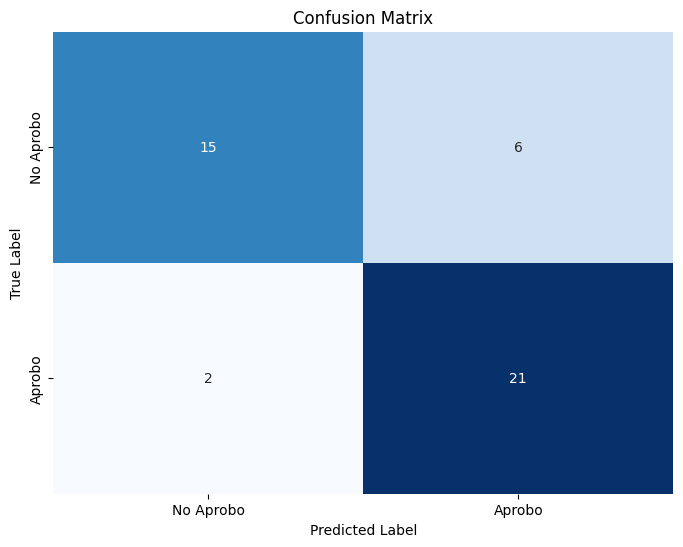

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Aprobo', 'Aprobo'], yticklabels=['No Aprobo', 'Aprobo'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Initialize the KNN model (using the same parameters as before)
knn_cv = KNeighborsClassifier(n_neighbors=7)

# Perform cross-validation
accuracy_scores = cross_val_score(knn_cv, X_resampled, y_resampled, cv=5, scoring='accuracy')
recall_scores = cross_val_score(knn_cv, X_resampled, y_resampled, cv=5, scoring='recall_macro') # Use macro average for imbalanced classes
precision_scores = cross_val_score(knn_cv, X_resampled, y_resampled, cv=5, scoring='precision_macro') # Use macro average for imbalanced classes


print("Cross-validation Accuracy scores:", accuracy_scores)
print("Mean Accuracy:", np.mean(accuracy_scores))
print("\nCross-validation Recall scores:", recall_scores)
print("Mean Recall:", np.mean(recall_scores))
print("\nCross-validation Precision scores:", precision_scores)
print("Mean Precision:", np.mean(precision_scores))

Cross-validation Accuracy scores: [0.61363636 0.55813953 0.62790698 0.69767442 0.6744186 ]
Mean Accuracy: 0.6343551797040169

Cross-validation Recall scores: [0.61363636 0.55627706 0.63095238 0.69805195 0.67316017]
Mean Recall: 0.6344155844155843

Cross-validation Precision scores: [0.61387164 0.55777778 0.6400463  0.69805195 0.6754386 ]
Mean Precision: 0.6370372508456033


In [25]:
# Load the second sheet of the Excel file

#df_sheet2 = pd.read_excel('/content/drive/MyDrive/Curso EAM 4/Carpeta del Curso Analítica Predictiva/Aprobacion curso 2019.xlsx', sheet_name=1)
df_sheet2 = pd.read_excel('../data/Aprobacion curso 2019.xlsx', sheet_name=1)
display(df_sheet2.head())

,ID,Año - Semestre,Felder,Examen_admisión
0,161,2019-01,activo,4.00
1,162,2019-01,visual,3.67
2,163,2019-01,equilibrio,4.50
3,164,2019-01,visual,3.00
4,165,2019-01,equilibrio,4.67


In [26]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Separate features (X) and target (y)
X = df_resampled.drop('Aprobo_Calculo', axis=1)
y = df_resampled['Aprobo_Calculo']

# Split data into training and testing sets (using a smaller test size for potentially more data in GridSearchCV)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'hidden_layer_sizes': [(150, 100, 50)], # 4 options
    'activation': ['tanh'], # 2 options
    'solver': ['adam'], # 2 options
    'alpha': [0.01], # 3 options
    'learning_rate': ['constant'], # 2 options
}
# Total combinations: 4 * 2 * 2 * 3 * 2 = 96

# Initialize MLPClassifier
mlp = MLPClassifier(max_iter=1000, random_state=42) # Increased max_iter for convergence

# Initialize GridSearchCV
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='accuracy', n_jobs=-1) # Use n_jobs=-1 for parallel processing

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found:", grid_search.best_params_)
print("Best accuracy found:", grid_search.best_score_)

# Evaluate the best model on the test set
best_mlp_model = grid_search.best_estimator_
y_pred = best_mlp_model.predict(X_test)

print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_pred))

Best parameters found: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (150, 100, 50), 'learning_rate': 'constant', 'solver': 'adam'}
Best accuracy found: 0.646218487394958

Classification Report on Test Set:
              precision    recall  f1-score   support

          no       0.77      0.81      0.79        21
          si       0.82      0.78      0.80        23

    accuracy                           0.80        44
   macro avg       0.80      0.80      0.80        44
weighted avg       0.80      0.80      0.80        44


Confusion Matrix on Test Set:
[[17  4]
 [ 5 18]]


In [27]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Separate features (X) and target (y) from the resampled data
X_resampled = df_resampled.drop('Aprobo_Calculo', axis=1)
y_resampled = df_resampled['Aprobo_Calculo']

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_neighbors': [4,5,6,7,8,9],
    'weights': ['uniform', 'distance']
}

# Initialize KNeighborsClassifier
knn = KNeighborsClassifier()

# Initialize GridSearchCV
grid_search_knn = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV
grid_search_knn.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found for KNN:", grid_search_knn.best_params_)
print("Best accuracy found for KNN:", grid_search_knn.best_score_)

# Evaluate the best KNN model on the test set
best_knn_model = grid_search_knn.best_estimator_
y_pred_knn = best_knn_model.predict(X_test)

print("\nClassification Report on Test Set (KNN):")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix on Test Set (KNN):")
print(confusion_matrix(y_test, y_pred_knn))

Best parameters found for KNN: {'n_neighbors': 8, 'weights': 'distance'}
Best accuracy found for KNN: 0.6749579831932773

Classification Report on Test Set (KNN):
              precision    recall  f1-score   support

          no       0.65      0.81      0.72        21
          si       0.78      0.61      0.68        23

    accuracy                           0.70        44
   macro avg       0.72      0.71      0.70        44
weighted avg       0.72      0.70      0.70        44


Confusion Matrix on Test Set (KNN):
[[17  4]
 [ 9 14]]


In [28]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Separate features (X) and target (y) from the resampled data
X_resampled = df_resampled.drop('Aprobo_Calculo', axis=1)
y_resampled = df_resampled['Aprobo_Calculo']

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'max_depth': [6, 7, 8], # 4 options
    'min_samples_split': [2, 3], # 3 options
    'min_samples_leaf': [2,3,4,5,6], # 3 options
    'criterion': ['entropy'] # 2 options
}
# Total combinations: 4 * 3 * 3 * 2 = 72 (Close to 96, can adjust if needed)

# Initialize DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_tree = GridSearchCV(tree, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV
grid_search_tree.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found for Decision Tree:", grid_search_tree.best_params_)
print("Best accuracy found for Decision Tree:", grid_search_tree.best_score_)

# Evaluate the best Decision Tree model on the test set
best_tree_model = grid_search_tree.best_estimator_
y_pred_tree = best_tree_model.predict(X_test)

print("\nClassification Report on Test Set (Decision Tree):")
print(classification_report(y_test, y_pred_tree))

print("\nConfusion Matrix on Test Set (Decision Tree):")
print(confusion_matrix(y_test, y_pred_tree))

Best parameters found for Decision Tree: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best accuracy found for Decision Tree: 0.7265546218487395

Classification Report on Test Set (Decision Tree):
              precision    recall  f1-score   support

          no       0.70      0.76      0.73        21
          si       0.76      0.70      0.73        23

    accuracy                           0.73        44
   macro avg       0.73      0.73      0.73        44
weighted avg       0.73      0.73      0.73        44


Confusion Matrix on Test Set (Decision Tree):
[[16  5]
 [ 7 16]]


In [29]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Separate features (X) and target (y) from the resampled data
X_resampled = df_resampled.drop('Aprobo_Calculo', axis=1)
y_resampled = df_resampled['Aprobo_Calculo']

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Initialize the base Decision Tree model (using the best parameters found previously)
base_tree = DecisionTreeClassifier(criterion='entropy', max_depth=7, min_samples_leaf=4, min_samples_split=2, random_state=42)

# Define the parameter grid for GridSearchCV for BaggingClassifier
param_grid_bagging = {
    'n_estimators': [7,8,9,10,11,12,13],  # Number of base estimators in the ensemble
    'max_samples': [0.6, 0.7, 0.8, 0.9, 1.0], # The number of samples to draw from X to train each base estimator
    'max_features': [0.6, 0.7, 0.8, 0.9, 1.0] # The number of features to draw from X to train each base estimator
}

# Initialize Bagging Classifier
bagging_gs = BaggingClassifier(estimator=base_tree, random_state=42)

# Initialize GridSearchCV
grid_search_bagging = GridSearchCV(bagging_gs, param_grid_bagging, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV
grid_search_bagging.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found for Bagging:", grid_search_bagging.best_params_)
print("Best accuracy found for Bagging:", grid_search_bagging.best_score_)

# Evaluate the best Bagging model on the test set
best_bagging_model = grid_search_bagging.best_estimator_
y_pred_bagging_gs = best_bagging_model.predict(X_test)

print("\nClassification Report on Test Set (Bagging with GridSearchCV):")
print(classification_report(y_test, y_pred_bagging_gs))

print("\nConfusion Matrix on Test Set (Bagging with GridSearchCV):")
print(confusion_matrix(y_test, y_pred_bagging_gs))

Best parameters found for Bagging: {'max_features': 0.8, 'max_samples': 0.7, 'n_estimators': 13}
Best accuracy found for Bagging: 0.7095798319327732

Classification Report on Test Set (Bagging with GridSearchCV):
              precision    recall  f1-score   support

          no       0.75      0.86      0.80        21
          si       0.85      0.74      0.79        23

    accuracy                           0.80        44
   macro avg       0.80      0.80      0.80        44
weighted avg       0.80      0.80      0.80        44


Confusion Matrix on Test Set (Bagging with GridSearchCV):
[[18  3]
 [ 6 17]]


In [30]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Separate features (X) and target (y) from the resampled data
X_resampled = df_resampled.drop('Aprobo_Calculo', axis=1)
y_resampled = df_resampled['Aprobo_Calculo']

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Initialize the base KNN model (using the best parameters found previously from the KNN GridSearchCV)
# Assuming the best KNN parameters from cell 3T9x591WnllN were {'n_neighbors': 7, 'weights': 'distance'}
base_knn = KNeighborsClassifier(n_neighbors=7, weights='distance')

# Define the parameter grid for GridSearchCV for BaggingClassifier
param_grid_bagging_knn = {
    'n_estimators': [10, 20, 30],  # Number of base estimators in the ensemble
    'max_samples': [0.8, 0.9, 1.0], # The number of samples to draw from X to train each base estimator
    'max_features': [0.8, 0.9, 1.0] # The number of features to draw from X to train each base estimator
}

# Initialize Bagging Classifier with KNN as the base estimator
bagging_knn_gs = BaggingClassifier(estimator=base_knn, random_state=42)

# Initialize GridSearchCV
grid_search_bagging_knn = GridSearchCV(bagging_knn_gs, param_grid_bagging_knn, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV
grid_search_bagging_knn.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found for Bagging with KNN:", grid_search_bagging_knn.best_params_)
print("Best accuracy found for Bagging with KNN:", grid_search_bagging_knn.best_score_)

# Evaluate the best Bagging with KNN model on the test set
best_bagging_knn_model = grid_search_bagging_knn.best_estimator_
y_pred_bagging_knn_gs = best_bagging_knn_model.predict(X_test)

print("\nClassification Report on Test Set (Bagging with KNN and GridSearchCV):")
print(classification_report(y_test, y_pred_bagging_knn_gs))

print("\nConfusion Matrix on Test Set (Bagging with KNN and GridSearchCV):")
print(confusion_matrix(y_test, y_pred_bagging_knn_gs))

Best parameters found for Bagging with KNN: {'max_features': 1.0, 'max_samples': 0.9, 'n_estimators': 30}
Best accuracy found for Bagging with KNN: 0.6628571428571429

Classification Report on Test Set (Bagging with KNN and GridSearchCV):
              precision    recall  f1-score   support

          no       0.70      0.76      0.73        21
          si       0.76      0.70      0.73        23

    accuracy                           0.73        44
   macro avg       0.73      0.73      0.73        44
weighted avg       0.73      0.73      0.73        44


Confusion Matrix on Test Set (Bagging with KNN and GridSearchCV):
[[16  5]
 [ 7 16]]


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Separate features (X) and target (y) from the resampled data
X_resampled = df_resampled.drop('Aprobo_Calculo', axis=1)
y_resampled = df_resampled['Aprobo_Calculo']

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Define the parameter grid for GridSearchCV for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [ 54,55,56], # Number of trees in the forest
    'max_depth': [3, 4, 5],      # Maximum depth of the trees
    'min_samples_split': [2], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]    # Minimum number of samples required to be at a leaf node
}

# Initialize RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV
grid_search_rf.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found for RandomForest:", grid_search_rf.best_params_)
print("Best accuracy found for RandomForest:", grid_search_rf.best_score_)

# Evaluate the best RandomForest model on the test set
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf_gs = best_rf_model.predict(X_test)

print("\nClassification Report on Test Set (RandomForest with GridSearchCV):")
print(classification_report(y_test, y_pred_rf_gs))

print("\nConfusion Matrix on Test Set (RandomForest with GridSearchCV):")
print(confusion_matrix(y_test, y_pred_rf_gs))

Best parameters found for RandomForest: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 55}
Best accuracy found for RandomForest: 0.6919327731092437

Classification Report on Test Set (RandomForest with GridSearchCV):
              precision    recall  f1-score   support

          no       0.73      0.90      0.81        21
          si       0.89      0.70      0.78        23

    accuracy                           0.80        44
   macro avg       0.81      0.80      0.79        44
weighted avg       0.81      0.80      0.79        44


Confusion Matrix on Test Set (RandomForest with GridSearchCV):
[[19  2]
 [ 7 16]]


In [32]:
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression # Using Logistic Regression as the final estimator
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Separate features (X) and target (y) from the resampled data
X_resampled = df_resampled.drop('Aprobo_Calculo', axis=1)
y_resampled = df_resampled['Aprobo_Calculo']

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Define base estimators
estimators = [
    ('knn', KNeighborsClassifier(n_neighbors=7, weights='distance')), # Using best KNN parameters from earlier
    ('tree', DecisionTreeClassifier(criterion='entropy', max_depth=7, min_samples_leaf=4, min_samples_split=2, random_state=42)) # Using best Decision Tree parameters from earlier
]

# Define the stacking classifier
# Using a simple Logistic Regression as the final estimator
stacking_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

# Define the parameter grid for GridSearchCV for the stacking classifier
# You can tune parameters of the base estimators and the final estimator here
param_grid_stacking = {
    'knn__n_neighbors': [8, 9, 10], # Tuning KNN's n_neighbors
    'tree__max_depth': [5, 6, 7], # Tuning Decision Tree's max_depth
    'final_estimator__C': [0.1, 1, 10] # Tuning Logistic Regression's C
}


# Initialize GridSearchCV
grid_search_stacking = GridSearchCV(stacking_model, param_grid_stacking, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV
grid_search_stacking.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found for Stacking:", grid_search_stacking.best_params_)
print("Best accuracy found for Stacking:", grid_search_stacking.best_score_)

# Evaluate the best Stacking model on the test set
best_stacking_model = grid_search_stacking.best_estimator_
y_pred_stacking_gs = best_stacking_model.predict(X_test)

print("\nClassification Report on Test Set (Stacking with GridSearchCV):")
print(classification_report(y_test, y_pred_stacking_gs))

print("\nConfusion Matrix on Test Set (Stacking with GridSearchCV):")
print(confusion_matrix(y_test, y_pred_stacking_gs))

Best parameters found for Stacking: {'final_estimator__C': 10, 'knn__n_neighbors': 8, 'tree__max_depth': 6}
Best accuracy found for Stacking: 0.686218487394958

Classification Report on Test Set (Stacking with GridSearchCV):
              precision    recall  f1-score   support

          no       0.70      0.76      0.73        21
          si       0.76      0.70      0.73        23

    accuracy                           0.73        44
   macro avg       0.73      0.73      0.73        44
weighted avg       0.73      0.73      0.73        44


Confusion Matrix on Test Set (Stacking with GridSearchCV):
[[16  5]
 [ 7 16]]


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Separate features (X) and target (y) from the resampled data
X_resampled = df_resampled.drop('Aprobo_Calculo', axis=1)
y_resampled = df_resampled['Aprobo_Calculo']

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate the model
print("Classification Report on Test Set (Logistic Regression):")
print(classification_report(y_test, y_pred_log_reg))

print("\nConfusion Matrix on Test Set (Logistic Regression):")
print(confusion_matrix(y_test, y_pred_log_reg))

Classification Report on Test Set (Logistic Regression):
              precision    recall  f1-score   support

          no       0.65      0.81      0.72        21
          si       0.78      0.61      0.68        23

    accuracy                           0.70        44
   macro avg       0.72      0.71      0.70        44
weighted avg       0.72      0.70      0.70        44


Confusion Matrix on Test Set (Logistic Regression):
[[17  4]
 [ 9 14]]


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Separate features (X) and target (y) from the resampled data
X_resampled = df_resampled.drop('Aprobo_Calculo', axis=1)
y_resampled = df_resampled['Aprobo_Calculo']

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Initialize and train the RandomForestClassifier model using the best parameters found earlier
# Best parameters found for RandomForest: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 55}
rf_model = RandomForestClassifier(n_estimators=55, max_depth=4, min_samples_split=2, min_samples_leaf=1, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Classification Report on Test Set (RandomForest Classifier):")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix on Test Set (RandomForest Classifier):")
print(confusion_matrix(y_test, y_pred_rf))

Classification Report on Test Set (RandomForest Classifier):
              precision    recall  f1-score   support

          no       0.74      0.95      0.83        21
          si       0.94      0.70      0.80        23

    accuracy                           0.82        44
   macro avg       0.84      0.82      0.82        44
weighted avg       0.85      0.82      0.82        44


Confusion Matrix on Test Set (RandomForest Classifier):
[[20  1]
 [ 7 16]]


In [36]:
import joblib

# Assuming 'best_rf_model' is the best RandomForest model trained with GridSearchCV
# in the previous steps (specifically in cell LkQmcj6v90Ua).
# Make sure that cell has been executed and the variable 'best_rf_model' exists.
joblib.dump(best_rf_model, '../scripts/models/clasificacion/rf_model.pkl')

print("Random Forest model saved as rf_model.pkl")

Random Forest model saved as rf_model.pkl
